# Validation 09 — RMS & CF for All 15 Bands (Cells 22–25)
Verifies bar charts, heatmap dimensions, and all-band grid plots.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time, warnings
from pathlib import Path
from scipy.signal import butter,cheby1,cheby2,ellip,bessel,sosfiltfilt,sosfreqz,welch
from scipy.signal import spectrogram as sp_spectrogram
from scipy.io import wavfile
from itertools import product
warnings.filterwarnings('ignore')

BASE_DIR    = Path(r"D:\\1 placement\\IAESTE INTERNSHIP CZECH\\iaeste26-blasting-sound-main\\iaeste26-blasting-sound-main")
DATA_DIR    = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SENSOR_PRIORITY   = ['AccAxial4507','AccRadial4507','Mic147EB','Mic46BE']
ENERGY_WINDOW_S   = 0.05;  NOISE_DURATION_S = 0.5;  ONSET_THRESHOLD = 10.0;  ONSET_OFFSET_S = 7.0
WINDOW_DURATION_S = 5.0;   WINDOW_STEP_S    = 1.0
LOWER_LIMITS = [176,225,283,353,440,565,707,880,1130,1414,1760,10,10,500,1000]
UPPER_LIMITS = [225,283,353,440,565,707,880,1130,1414,1760,2220,1000,2000,1500,2000]
N_BANDS      = len(LOWER_LIMITS)
BAND_LABELS  = [f"{lo}–{hi} Hz" for lo,hi in zip(LOWER_LIMITS,UPPER_LIMITS)]
FILTER_TYPES  = ['Butterworth','Chebyshev I','Chebyshev II','Elliptical','Bessel']
FILTER_ORDERS = [3,5,7]
CHEBY1_RIPPLE_DB=0.5; CHEBY2_ATTEN_DB=40.0; ELLIP_RIPPLE_DB=0.5; ELLIP_ATTEN_DB=40.0

P=[0]; F=[0]
def check(label, ok, note=""):
    s="[PASS]" if ok else "[FAIL]"
    if ok: P[0]+=1
    else:  F[0]+=1
    print(f"  {s}  {label}" + (f"  → {note}" if note else ""))
def info(label, val): print(f"  [INFO]  {label}: {val}")
def summary():
    t=P[0]+F[0]
    print(f"\n{'='*50}")
    print(f"  PASS: {P[0]}/{t}  |  FAIL: {F[0]}/{t}")
    print(f"  Score: {P[0]/t*100:.0f}%" if t else "  No checks run")
    print('='*50)
print("Config loaded.")


Config loaded.


Loaded 20,025 rows from CSV
  [PASS]  RMS bars [Butterworth N=3]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Chebyshev I N=3]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Chebyshev II N=3]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Elliptical N=3]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Bessel N=3]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Butterworth N=5]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Chebyshev I N=5]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Chebyshev II N=5]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Elliptical N=5]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Bessel N=5]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Butterworth N=7]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Chebyshev I N=7]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Chebyshev II N=7]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Elliptical N=7]: 15 bars, all ≥ 0
  [PASS]  RMS bars [Bessel N=7]: 15 bars, all ≥ 0


  [PASS]  CF matrix shape = (15, 15)
  [PASS]  No all-NaN row in CF matrix
  [PASS]  All CF values ≥ 1  → min=5.491
  [PASS]  95th-pct clip < max
  [PASS]  Grid covers all bands  → 3×5≥15
  [PASS]  filter_colors has 5 entries
  [PASS]  All bands have data at order 5


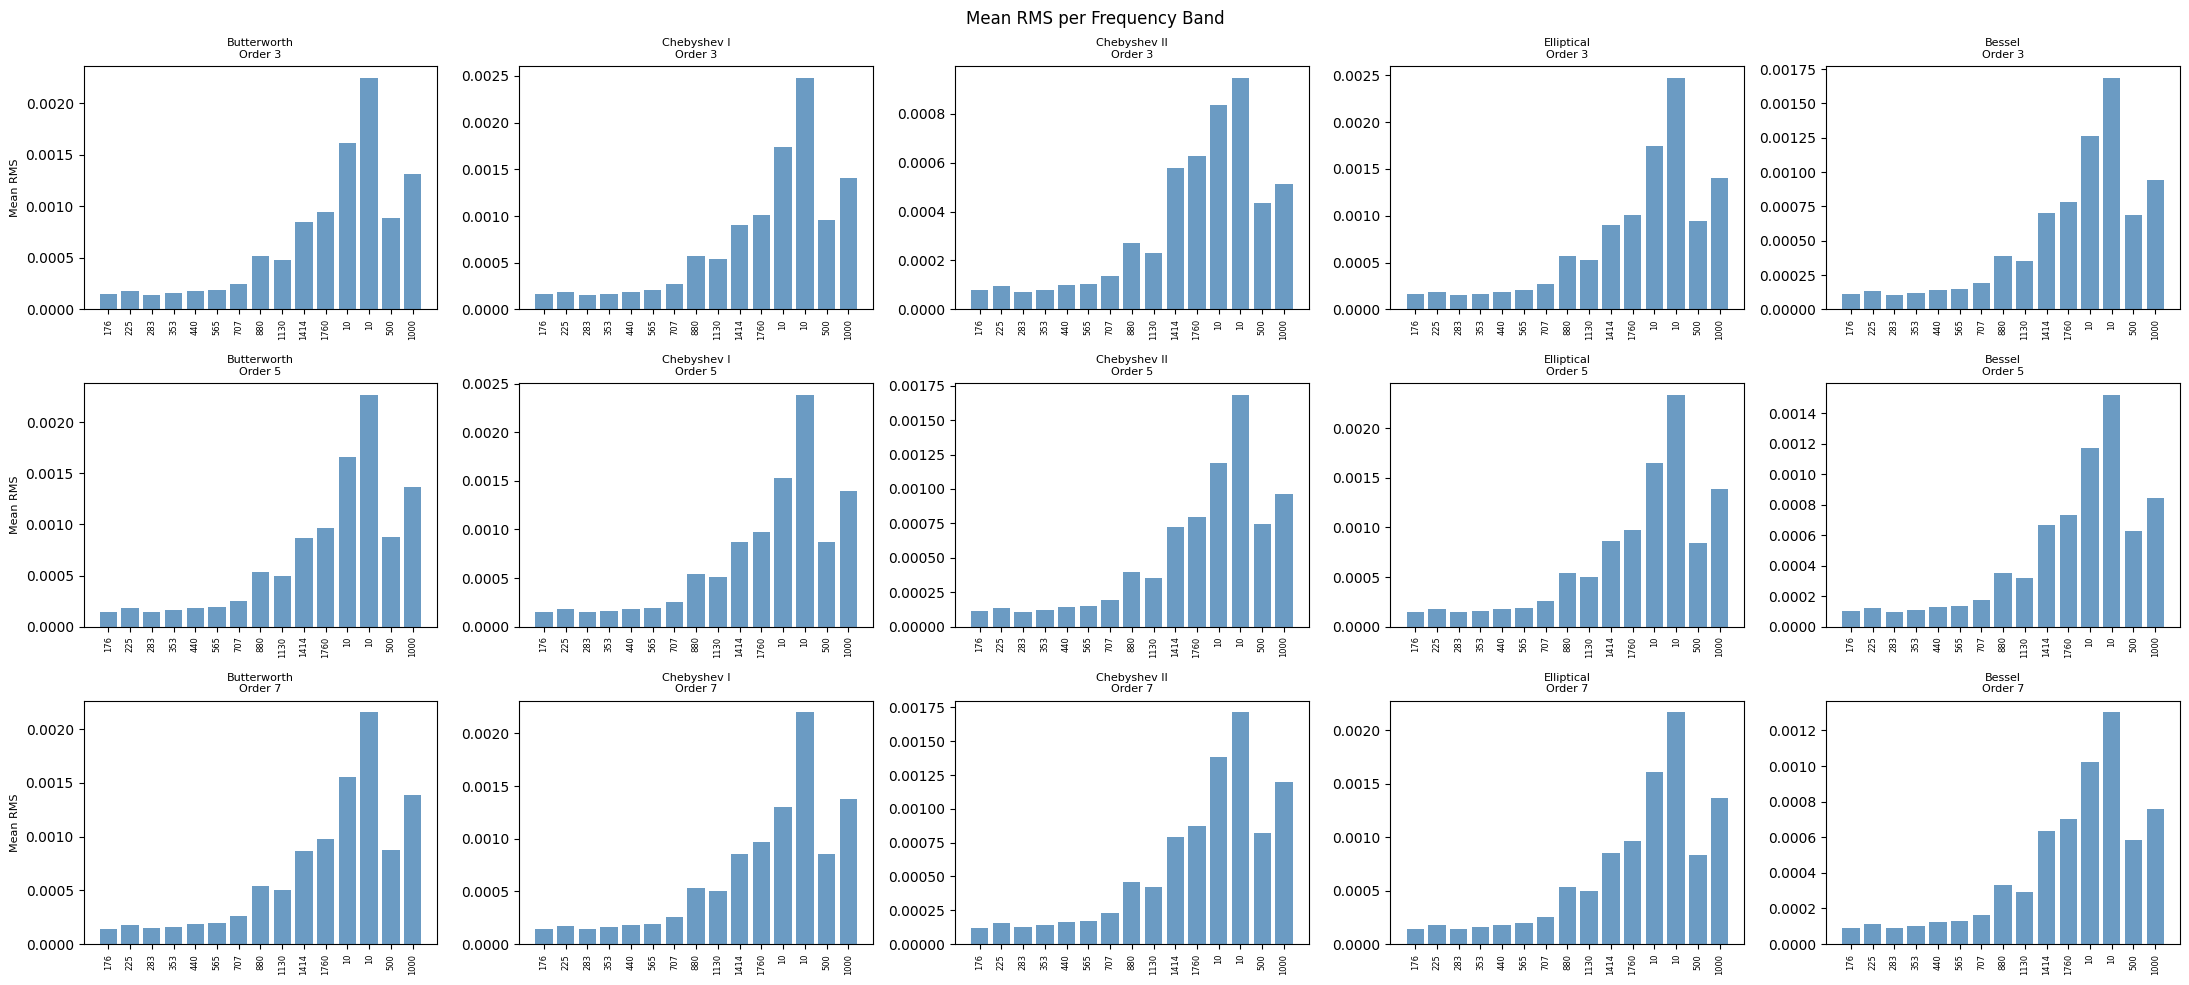

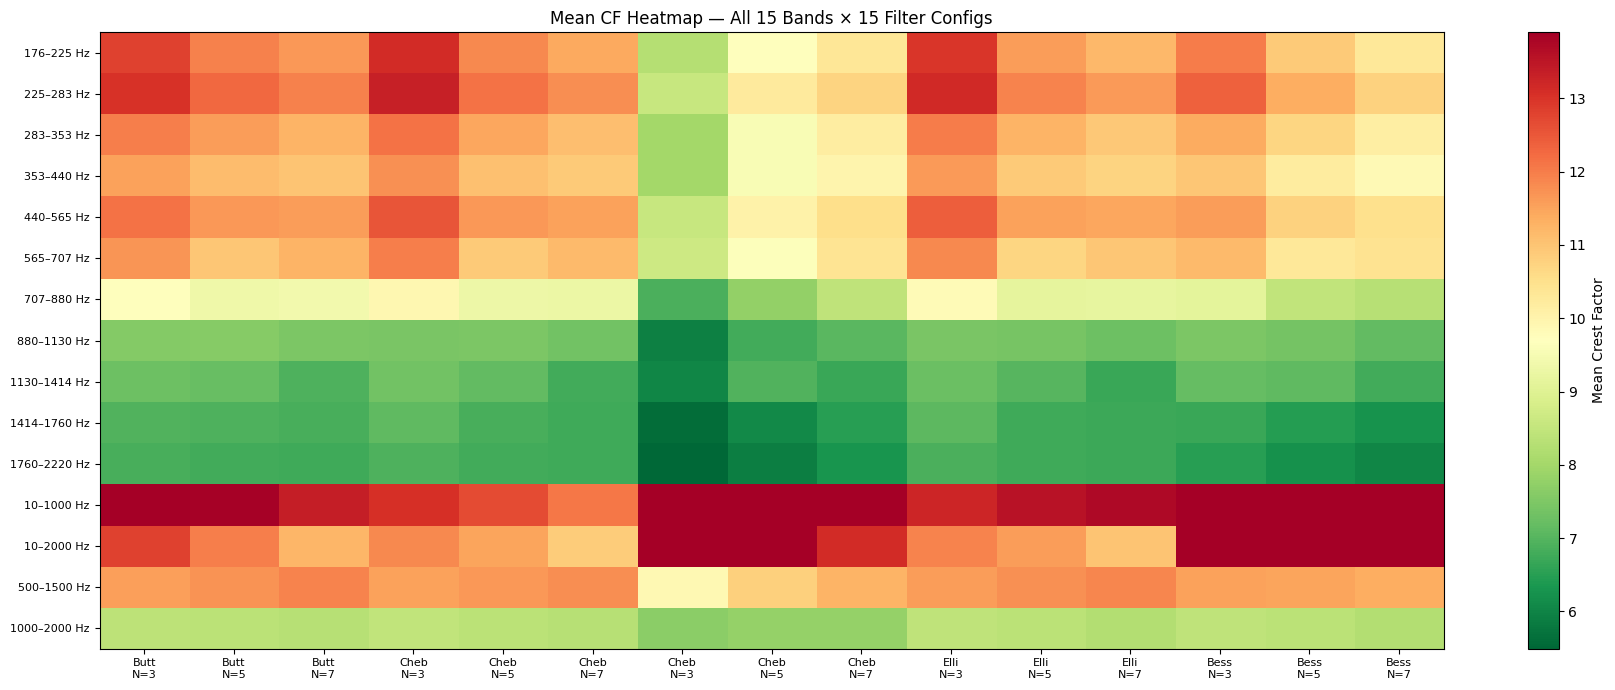

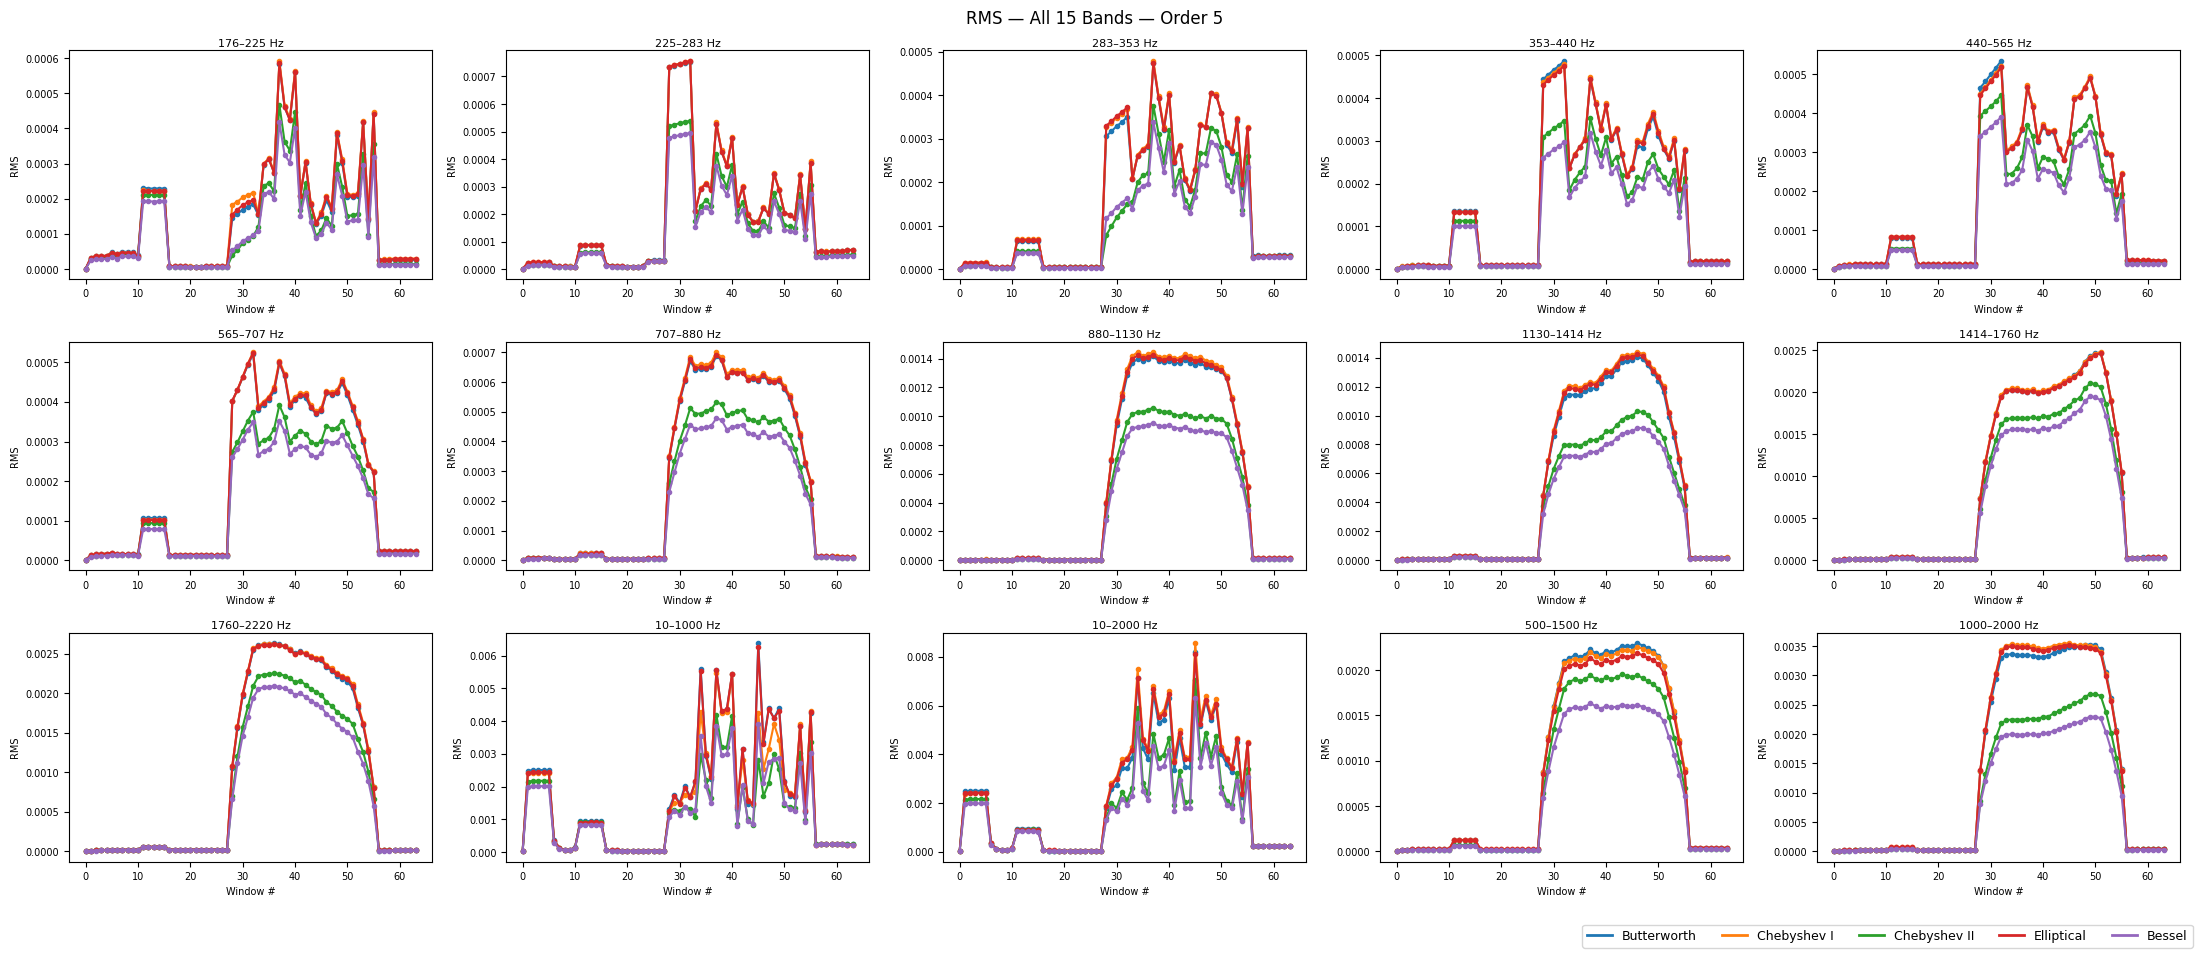

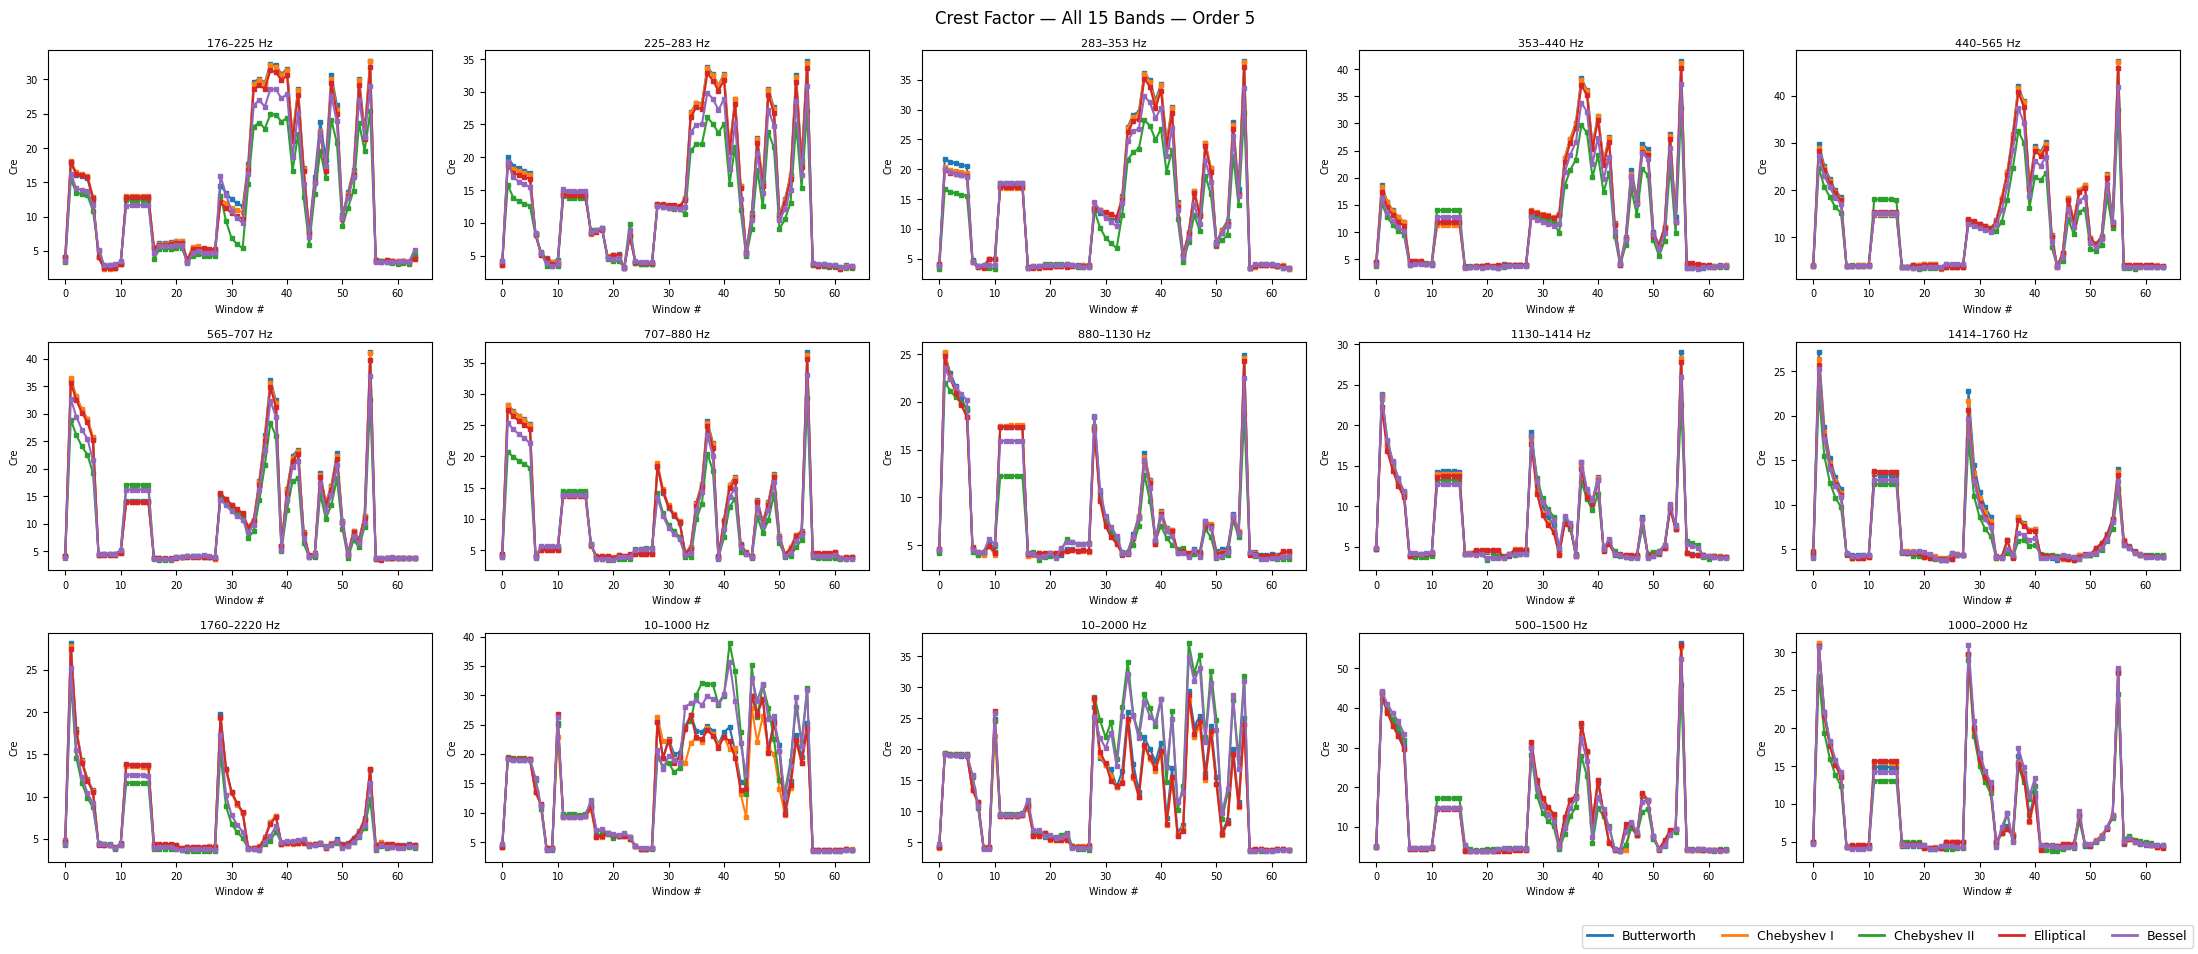


  PASS: 22/22  |  FAIL: 0/22
  Score: 100%


In [2]:
csv_path = RESULTS_DIR/"blasting_all_results.csv"
if not csv_path.exists():
    print("[SKIP] Run validation_08 first to generate blasting_all_results.csv"); raise SystemExit
df=pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows from CSV")

# ── Cell 22: RMS bar charts ───────────────────────────────────────────────────
df_first=df[df['file_idx']==0] if 'file_idx' in df.columns else df
for order in FILTER_ORDERS:
    for ftype in FILTER_TYPES:
        sub=df_first[(df_first.filter_type==ftype)&(df_first.order==order)]
        vals=sub.groupby('band_idx')['rms'].mean().reindex(range(N_BANDS),fill_value=0.)
        check(f"RMS bars [{ftype} N={order}]: {N_BANDS} bars, all ≥ 0",
              len(vals)==N_BANDS and (vals>=0).all())

# ── Cell 23: CF heatmap ───────────────────────────────────────────────────────
n_combos=len(FILTER_TYPES)*len(FILTER_ORDERS)
cf_mat=np.full((N_BANDS,n_combos),np.nan)
for col,(ft,ord_) in enumerate(product(FILTER_TYPES,FILTER_ORDERS)):
    for row in range(N_BANDS):
        sub=df[(df.filter_type==ft)&(df.order==ord_)&(df.band_idx==row)]
        if len(sub): cf_mat[row,col]=sub['crest_factor'].mean()
check("CF matrix shape = (15, 15)",        cf_mat.shape==(N_BANDS,n_combos))
check("No all-NaN row in CF matrix",       not np.all(np.isnan(cf_mat),axis=1).any())
check("All CF values ≥ 1",                 np.nanmin(cf_mat)>=1.0,  f"min={np.nanmin(cf_mat):.3f}")
check("95th-pct clip < max",               np.nanpercentile(cf_mat,95)<np.nanmax(cf_mat)*2)

# ── Cells 24–25: All-band grid ────────────────────────────────────────────────
FOCUS_ORDER=5
df_ref=df[df['file_idx']==0] if 'file_idx' in df.columns else df
n_cols=5; n_rows=int(np.ceil(N_BANDS/n_cols))
filter_colors={'Butterworth':'#1f77b4','Chebyshev I':'#ff7f0e',
               'Chebyshev II':'#2ca02c','Elliptical':'#d62728','Bessel':'#9467bd'}
check("Grid covers all bands",    n_rows*n_cols>=N_BANDS,  f"{n_rows}×{n_cols}≥{N_BANDS}")
check("filter_colors has 5 entries", len(filter_colors)==5)
check("All bands have data at order 5",
      df_ref[df_ref.order==FOCUS_ORDER]['band_idx'].nunique()==N_BANDS)

# ── Plot Cell 22 ──────────────────────────────────────────────────────────────
fig,axes=plt.subplots(len(FILTER_ORDERS),len(FILTER_TYPES),figsize=(22,10),sharey=False)
for r,order in enumerate(FILTER_ORDERS):
    for c,ftype in enumerate(FILTER_TYPES):
        ax=axes[r,c]
        sub=df_first[(df_first.filter_type==ftype)&(df_first.order==order)]
        vals=sub.groupby('band_idx')['rms'].mean().reindex(range(N_BANDS),fill_value=0.)
        ax.bar(range(N_BANDS),vals,color='steelblue',alpha=0.8)
        ax.set_title(f'{ftype}\nOrder {order}',fontsize=8)
        ax.set_xticks(range(N_BANDS)); ax.set_xticklabels([str(l) for l in LOWER_LIMITS],rotation=90,fontsize=6)
        if c==0: ax.set_ylabel('Mean RMS',fontsize=8)
fig.suptitle('Mean RMS per Frequency Band',fontsize=12); plt.tight_layout(); plt.show(); plt.close('all')

# ── Plot Cell 23: CF Heatmap ──────────────────────────────────────────────────
combo_labels=[f"{ft[:4]}\nN={o}" for ft,o in product(FILTER_TYPES,FILTER_ORDERS)]
fig,ax=plt.subplots(figsize=(18,7))
im=ax.imshow(cf_mat,aspect='auto',cmap='RdYlGn_r',interpolation='nearest',
             vmin=np.nanmin(cf_mat),vmax=np.nanpercentile(cf_mat,95))
plt.colorbar(im,ax=ax,label='Mean Crest Factor')
ax.set_xticks(range(n_combos)); ax.set_xticklabels(combo_labels,fontsize=8)
ax.set_yticks(range(N_BANDS)); ax.set_yticklabels(BAND_LABELS,fontsize=8)
ax.set_title('Mean CF Heatmap — All 15 Bands × 15 Filter Configs')
plt.tight_layout(); plt.show(); plt.close('all')

# ── Plots Cells 24–25: All-band grids ────────────────────────────────────────
handles=[plt.Line2D([0],[0],color=filter_colors[ft],lw=2,label=ft) for ft in FILTER_TYPES]
for param,marker,ptitle in [('rms','o','RMS'),('crest_factor','s','Crest Factor')]:
    fig,axes=plt.subplots(n_rows,n_cols,figsize=(22,n_rows*3.2),sharey=False)
    af=axes.flatten()
    for bi in range(N_BANDS):
        ax=af[bi]
        for ft in FILTER_TYPES:
            sub=df_ref[(df_ref.filter_type==ft)&(df_ref.order==FOCUS_ORDER)&(df_ref.band_idx==bi)].sort_values('window_idx')
            if len(sub)==0: continue
            ax.plot(sub['window_idx'],sub[param],color=filter_colors[ft],lw=1.5,marker=marker,markersize=3)
        ax.set_title(BAND_LABELS[bi],fontsize=8,pad=3)
        ax.set_xlabel('Window #',fontsize=7); ax.set_ylabel(ptitle[:3],fontsize=7); ax.tick_params(labelsize=7)
    for ax in af[N_BANDS:]: ax.set_visible(False)
    fig.legend(handles=handles,loc='lower right',fontsize=9,ncol=5)
    fig.suptitle(f'{ptitle} — All {N_BANDS} Bands — Order {FOCUS_ORDER}',fontsize=12)
    plt.tight_layout(rect=[0,0.04,1,1]); plt.show(); plt.close('all')
summary()
